## Packages and env setup

In [1]:
# %pip install datasets

In [2]:
# pip install matplotlib

## Constants

In [3]:
from transformers import AutoTokenizer

In [ ]:
model_name = 'EleutherAI/gpt-neo-1.3B'
dataset_name = 'tatsu-lab/alpaca'

batch_size = 8
epochs = 3
lr = 2e-5

## Tokenizer

In [5]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## Load data

In [6]:
from datasets import load_dataset
dataset = load_dataset(dataset_name)

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 52002
    })
})

In [8]:
split = dataset["train"].shuffle(seed=42).select(range(10000)).train_test_split(test_size=0.2)

train_dataset = split["train"]
val_dataset = split["test"]

In [9]:
train_dataset[:4]

{'instruction': ['What is the surface area of a cube whose edges are 6 ft long?',
  'Write a comment in HTML that describes the purpose of the webpage.',
  'Paraphrase the following sentence. Output a full sentence.',
  'What was the capital of France in the 1900s?'],
 'input': ['', '', 'This job is too hard to complete.', ''],
 'output': ['The surface area of a cube with 6 ft long edges is 216 sq ft.',
  '<!-- This webpage is an online store where customers can browse and purchase a variety of products -->',
  'This job is too difficult to finish.',
  'Paris was the capital of France in the 1900s.'],
 'text': ['Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nWhat is the surface area of a cube whose edges are 6 ft long?\n\n### Response:\nThe surface area of a cube with 6 ft long edges is 216 sq ft.',
  'Below is an instruction that describes a task. Write a response that appropriately completes the request.\

In [10]:
REWARD_TOKEN_ID = tokenizer.eos_token_id

In [11]:
REWARD_TOKEN_ID

50256

## Tokenization

In [12]:
def tokenize(batch):

    texts = []

    for ins, inp, out in zip(
        batch["instruction"],
        batch["input"],
        batch["output"]
    ):
        text = f"Instruction: {ins}\nInput: {inp}\nResponse: {out}"
        texts.append(text)

    tokenized = tokenizer(
        texts,
        padding=False,
        truncation=True,
        max_length=512
    )

    return tokenized

In [13]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True,
    remove_columns=val_dataset.column_names
)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [14]:
train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")

## Data loader

In [15]:
from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding
)
from torch.utils.data import DataLoader


In [16]:
data_collator = DataCollatorWithPadding(tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=data_collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    collate_fn=data_collator
)

In [17]:
# tokenized_dataset_train = tokenized_dataset_train.filter(lambda x: len(x['input_ids']) > 5)
# tokenized_dataset_val = tokenized_dataset_val.filter(lambda x: len(x['input_ids']) > 5)

In [18]:
# len(tokenized_dataset_train), len(tokenized_dataset_val)

In [19]:
import torch

In [20]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## Reward Model

In [21]:

from torch import nn
import numpy as np
from transformers import AutoModelForCausalLM

class RewardModel(nn.Module):
  def __init__(self, model_name):
      super().__init__()

      self.transformer = AutoModel.from_pretrained(model_name)

      hidden_size = self.transformer.config.hidden_size

      self.reward_head = nn.Linear(hidden_size, 1)

  def forward(self, input_ids, attention_mask):

      outputs = self.transformer(
          input_ids=input_ids,
          attention_mask=attention_mask
      )

      hidden = outputs.last_hidden_state

      last_token = hidden[:, -1, :]

      reward = self.reward_head(last_token)

      return reward.squeeze(-1)

In [22]:
model = RewardModel(model_name).to(device)

/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [23]:
class GPT2RewardModel(nn.Module):

    def __init__(self, model_name):
        super().__init__()

        self.transformer = AutoModel.from_pretrained(model_name)

        hidden_size = self.transformer.config.hidden_size

        self.reward_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):

        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden_states = outputs.last_hidden_state

        last_token = hidden_states[:, -1, :]

        reward = self.reward_head(last_token)

        return reward.squeeze(-1)

In [24]:
model = GPT2RewardModel(model_name).to(device)

## Optimizer

In [25]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

criterion = nn.MSELoss()

## Validation

In [26]:
def validate():

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for batch in val_loader:

            batch = {k: v.to(device) for k, v in batch.items()}

            rewards = model(
                batch["input_ids"],
                batch["attention_mask"]
            )

            targets = torch.ones_like(rewards)

            loss = criterion(rewards, targets)

            total_loss += loss.item()

    avg_val_loss = total_loss / len(val_loader)
    print("Validation Loss:", avg_val_loss)
    return avg_val_loss

In [27]:
len(train_loader)

1000

## Training

In [28]:
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

In [29]:
for epoch in range(epochs):

    model.train()
    epoch_loss = 0
    batch_count = 0

    for i, batch in enumerate(train_loader, 1):
        batch = {k: v.to(device) for k, v in batch.items()}

        rewards = model(
            batch["input_ids"],
            batch["attention_mask"]
        )

        targets = torch.ones_like(rewards)

        loss = criterion(rewards, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_count += 1

        print("loss:", loss.item())
        if i % 100 == 0:
            print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}")

    # Average training loss for the epoch
    avg_train_loss = epoch_loss / batch_count
    train_losses.append(avg_train_loss)

    val_loss = validate()
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}")

loss: 29.64423179626465
loss: 25.858922958374023
loss: 15.418120384216309
loss: 14.039117813110352
loss: 10.917470932006836
loss: 13.803546905517578
loss: 5.965571403503418
loss: 7.2511396408081055
loss: 4.70478630065918
loss: 2.7575583457946777
loss: 2.359575033187866
loss: 1.920355200767517
loss: 0.6474812626838684
loss: 0.8677631616592407
loss: 0.8988951444625854
loss: 1.5564274787902832
loss: 1.457998275756836
loss: 0.8059279918670654
loss: 0.45004794001579285
loss: 2.847782611846924
loss: 0.6893091201782227
loss: 1.1765059232711792
loss: 0.6561422348022461
loss: 1.545643925666809
loss: 0.4654082953929901
loss: 0.42015907168388367
loss: 0.6633205413818359
loss: 0.6398860216140747
loss: 0.07000572979450226
loss: 0.2858026325702667
loss: 0.34682801365852356
loss: 0.48390108346939087
loss: 0.13921737670898438
loss: 0.22620894014835358
loss: 0.11388963460922241
loss: 0.1884385049343109
loss: 0.41388338804244995
loss: 0.10433661192655563
loss: 0.29107552766799927
loss: 0.185692310333251

## Visualization

In [30]:
print(train_losses, val_losses)

[0.18919491608126554, 0.007578648187569342, 0.004550887773162685] [0.004285933044739068, 0.0013978211433859542, 0.0013909225208917633]


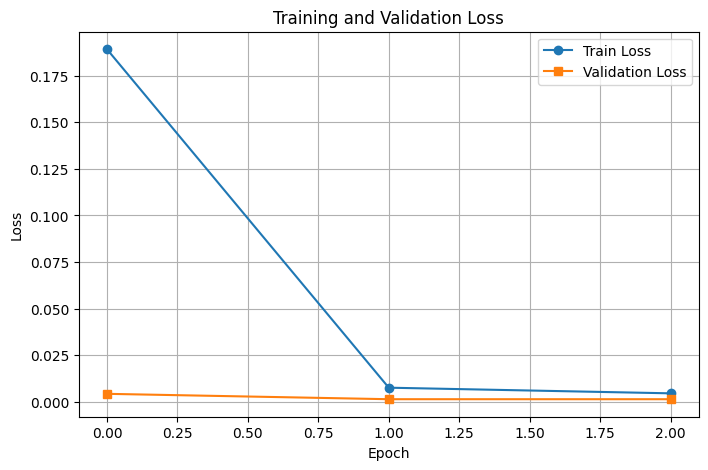

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='s', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

In [52]:
def reward_statistics():

    model.eval()

    rewards_all = []

    with torch.no_grad():

        for batch in val_loader:

            batch = {k: v.to(device) for k, v in batch.items()}

            rewards = model(
                batch["input_ids"],
                batch["attention_mask"]
            )

            rewards_all.extend(rewards.cpu().numpy())

    rewards_all = np.array(rewards_all)

    print("Mean reward:", rewards_all.mean())
    print("Std reward:", rewards_all.std())
    print("Min reward:", rewards_all.min())
    print("Max reward:", rewards_all.max())

reward_statistics()

Mean reward: 1.0255642
Std reward: 0.027155014
Min reward: 0.7637422
Max reward: 1.1725894


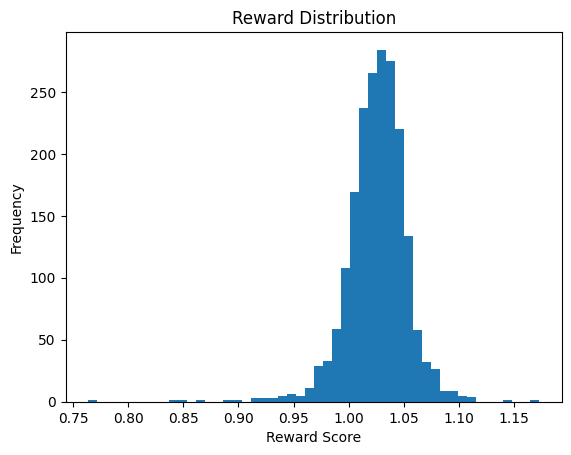

In [53]:
def plot_rewards():

    model.eval()

    rewards_all = []

    with torch.no_grad():
        for batch in val_loader:

            batch = {k: v.to(device) for k, v in batch.items()}

            rewards = model(
                batch["input_ids"],
                batch["attention_mask"]
            )

            rewards_all.extend(rewards.cpu().numpy())

    plt.hist(rewards_all, bins=50)
    plt.xlabel("Reward Score")
    plt.ylabel("Frequency")
    plt.title("Reward Distribution")
    plt.show()

plot_rewards()

In [32]:
# from torch.utils.data import DataLoader
# from transformers import DataCollatorWithPadding

# tokenizer.pad_token = tokenizer.eos_token
# data_collator = DataCollatorWithPadding(tokenizer)
# dataloader_param = {
#     "batch_size": 64,
#     "collate_fn": data_collator,
#     "shuffle": True
# }
# train_dataloader = DataLoader(tokenized_dataset_train, **dataloader_param)
# val_dataloader = DataLoader(tokenized_dataset_val, **dataloader_param)

In [33]:
# batch = next(iter(train_dataloader))
# print(batch.keys())

In [34]:
# print(batch["input_ids"][1])

In [35]:
# print(tokenizer.decode(batch['input_ids'][1]))

In [36]:
# batch['attention_mask'][1].nonzero()[-1]

In [37]:
# outputs = model(batch['input_ids'], batch['attention_mask'])

In [38]:
# print(outputs.shape)

In [39]:
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
# criterion = nn.BCELoss()
# num_epochs = 1

In [40]:
# device

In [41]:
# print(inputs["score"].min(), inputs["score"].max())


In [42]:
# model.to(device)

In [43]:
# def validate():
#   model.eval()
#   total_loss=0.0
#   for i, batch in enumerate(val_dataloader):
#     inputs = batch.to(device)
#     model_inputs = {
#         "input_ids": inputs["input_ids"],
#         "attention_mask": inputs["attention_mask"]
#     }
#     with torch.no_grad():
#       scores = model(**model_inputs)
#       batch_indices = torch.arange(scores.shape[0])
#       score = scores[batch_indices, inputs["score_index"]]
#       target = inputs["score"]
#       loss = criterion(score, target)
#     total_loss += loss.item()
#   print(f'validation loss: {total_loss/len(val_dataloader)}')

In [44]:
# model.to(device)

# validate()
# for epoch in range(num_epochs):
#     model.train()
#     for i, batch in enumerate(train_dataloader):
#         inputs = batch.to(device)
#         model_inputs = {
#             'input_ids': inputs['input_ids'],
#             'attention_mask': inputs['attention_mask']
#         }
#         scores = model(**model_inputs)
#         batch_indices = torch.arange(scores.shape[0])
#         score = scores[batch_indices, inputs['score_index']]
#         target = inputs['score']
#         loss = criterion(score, target)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         print(loss.item())
#     validate()

## Save Model

In [45]:
saving_format = f'{model_name.split('/')[-1]}-{dataset_name.split('/')[-1]}'

In [ ]:
torch.save(model.state_dict(), f'reward_model-{saving_format}.pt')
torch.save(model.state_dict(), 'rewardmodel.pt')
torch.save(model.state_dict(), 'reward_model.pt')

In [47]:
validate()

Validation Loss: 0.0013909225208917633


0.0013909225208917633

In [48]:
sample_text = "Instruction: Write a short poem about AI.\nInput: None\nResponse: AI learns and grows each day, making the world bright in every way."

# Tokenize
inputs = tokenizer(
    sample_text,
    return_tensors="pt",   # returns batch dimension
    truncation=True,
    max_length=512,
    padding=True           # use pad token
)

# Move to device
inputs = {k: v.to(device) for k, v in inputs.items()}

In [49]:
model.eval()
with torch.no_grad():
    reward = model(inputs["input_ids"], inputs["attention_mask"])

In [50]:
print("Reward score:", reward.item())

Reward score: 1.07314932346344


In [51]:
# from sklearn.metrics import confusion_matrix
# model.eval()

# all_predictions = []
# all_labels = []

# for i, batch in enumerate(val_dataloader):
#   input = batch.to(device)
#   model_inputs = {
#       "input_ids": input["input_ids"],
#       "attention_mask": input["attention_mask"]
#   }
#   with torch.no_grad():
#     scores = model(**model_inputs)
#     batch_indices = torch.arange(scores.shape[0])
#     score = scores[batch_indices, inputs["score_index"]]
#     target = inputs["score"]
#   predictions = (score > 0.5).int()

#   all_predictions.extend(predictions.cpu().numpy())
#   all_labels.extend(target.cpu().numpy())

# confusion_matrix(all_labels, all_predictions)